# EDA da Unidade Movel Madureira

Este notebook será usado para a análise exploratória individual da **Unidade Movel Madureira**. Nesta primeira etapa, vamos montar a **auditoria da base**, que serve para verificar se a série da Unidade Movel é confiável e em quais períodos ela apresenta melhor ou pior qualidade.


## Carregamento da base

Primeiro, carregamos a base consolidada de qualidade do ar e isolamos apenas os registros da Unidade Movel de Madureira. Como o nome da Unidade Movel pode vir com problema de codificação, fazemos uma normalização simples para garantir um filtro robusto.


In [1]:
import pandas as pd
import unicodedata
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_madureira = df_air_quality[df_air_quality["Nome"] == "UNIDADE MOVEL MADUREIRA"].copy()

print("Dimensoes da base da Unidade Movel Madureira:", df_madureira.shape)
display(df_madureira.head())

Dimensoes da base da Unidade Movel Madureira: (3490, 15)


,data,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
157479,2014-01-14 10:30:00,UNIDADE MOVEL MADUREIRA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.0,-22.865555,-43.343363
157493,2014-01-14 11:30:00,UNIDADE MOVEL MADUREIRA,0.0,33.93,50.43,19.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-22.865555,-43.343363
157500,2014-01-14 12:30:00,UNIDADE MOVEL MADUREIRA,0.0,35.38,43.70,NaN,NaN,0.38,NaN,NaN,NaN,NaN,50.0,-22.865555,-43.343363
157510,2014-01-14 13:30:00,UNIDADE MOVEL MADUREIRA,0.0,36.30,40.38,NaN,NaN,0.18,NaN,NaN,112.89,NaN,13.0,-22.865555,-43.343363
157521,2014-01-14 14:30:00,UNIDADE MOVEL MADUREIRA,0.0,36.52,38.37,16.68,NaN,NaN,NaN,NaN,130.70,NaN,12.0,-22.865555,-43.343363


## Auditoria da base


### 1. Período coberto e frequência observada

Nesta célula verificamos o intervalo temporal da base, o número de timestamps únicos, o intervalo mais frequente entre observações e a distribuição do minuto da medição. Isso ajuda a confirmar se a série realmente se comporta como uma série **horária**.


In [3]:
df_madureira["data"] = pd.to_datetime(df_madureira["data"], errors="coerce")

timestamps_unicos = df_madureira["data"].drop_duplicates().sort_values()
intervalos = timestamps_unicos.diff().dropna()

intervalo_modal = intervalos.mode().iloc[0] if not intervalos.empty else pd.Timedelta(hours=1)

resumo_periodo = pd.DataFrame(
    {
        "metrica": [
            "primeira_medicao",
            "ultima_medicao",
            "n_linhas",
            "anos_cobertos",
        ],
        "valor": [
            timestamps_unicos.min(),
            timestamps_unicos.max(),
            len(df_madureira),
            df_madureira["data"].dt.year.nunique(),
        ],
    }
)

display(resumo_periodo)

,metrica,valor
0,primeira_medicao,2014-01-14 10:30:00
1,ultima_medicao,2014-08-12 14:30:00
2,n_linhas,3490
3,anos_cobertos,1


### 2. Datas faltantes e cobertura temporal

Agora montamos um calendário esperado usando o intervalo modal da série e verificamos:

- quantos timestamps estão faltando no período total;
- quais são alguns exemplos de lacunas;
- como a **completude** se comporta por ano e por mês.

Esse bloco é importante porque, mesmo que a Unidade Movel tenha um período longo, ela pode ter meses com baixa confiabilidade.


In [4]:
indice_esperado = pd.date_range(timestamps_unicos.min(), timestamps_unicos.max(), freq=intervalo_modal)
timestamps_faltantes = indice_esperado.difference(timestamps_unicos)

print("Quantidade de timestamps esperados:", len(indice_esperado))
print("Quantidade de timestamps observados:", len(timestamps_unicos))
print("Quantidade de timestamps faltantes:", len(timestamps_faltantes))

if len(timestamps_faltantes) > 0:
    display(pd.DataFrame({"data_faltante": timestamps_faltantes[:20]}))
else:
    print("Nao foram encontrados timestamps faltantes na serie.")

df_cobertura = pd.DataFrame({"data": indice_esperado})
df_cobertura["observada"] = df_cobertura["data"].isin(timestamps_unicos).astype(int)
df_cobertura["ano"] = df_cobertura["data"].dt.year
df_cobertura["mes"] = df_cobertura["data"].dt.month
df_cobertura["ano_mes"] = df_cobertura["data"].dt.to_period("M").astype(str)

cobertura_anual = (
    df_cobertura.groupby("ano", as_index=False)
    .agg(
        medicoes_esperadas=("observada", "size"),
        medicoes_observadas=("observada", "sum"),
    )
)
cobertura_anual["faltantes"] = cobertura_anual["medicoes_esperadas"] - cobertura_anual["medicoes_observadas"]
cobertura_anual["completude_pct"] = (100 * cobertura_anual["medicoes_observadas"] / cobertura_anual["medicoes_esperadas"]).round(2)

cobertura_mensal = (
    df_cobertura.groupby(["ano_mes", "ano", "mes"], as_index=False)
    .agg(
        medicoes_esperadas=("observada", "size"),
        medicoes_observadas=("observada", "sum"),
    )
)
cobertura_mensal["faltantes"] = cobertura_mensal["medicoes_esperadas"] - cobertura_mensal["medicoes_observadas"]
cobertura_mensal["completude_pct"] = (100 * cobertura_mensal["medicoes_observadas"] / cobertura_mensal["medicoes_esperadas"]).round(2)

display(cobertura_anual)
display(cobertura_mensal.sort_values(["completude_pct", "ano_mes"]).head(15))

Quantidade de timestamps esperados: 5045
Quantidade de timestamps observados: 3490
Quantidade de timestamps faltantes: 1555


,data_faltante
0,2014-02-28 21:30:00
1,2014-02-28 22:30:00
2,2014-02-28 23:30:00
3,2014-03-01 00:30:00
4,2014-03-01 01:30:00
5,2014-03-01 02:30:00
6,2014-03-01 03:30:00
7,2014-03-01 04:30:00
8,2014-03-01 05:30:00
9,2014-03-01 06:30:00


,ano,medicoes_esperadas,medicoes_observadas,faltantes,completude_pct
0,2014,5045,3490,1555,69.18


,ano_mes,ano,mes,medicoes_esperadas,medicoes_observadas,faltantes,completude_pct
3,2014-04,2014,4,720,0,720,0.00
2,2014-03,2014,3,744,167,577,22.45
4,2014-05,2014,5,744,490,254,65.86
1,2014-02,2014,2,672,669,3,99.55
5,2014-06,2014,6,720,719,1,99.86
0,2014-01,2014,1,422,422,0,100.00
6,2014-07,2014,7,744,744,0,100.00
7,2014-08,2014,8,279,279,0,100.00


### 3. Colunas totalmente vazias e percentual de missing por variável

Nesta etapa medimos a completude de cada coluna. Isso ajuda a responder, por exemplo, se algum poluente praticamente não existe na série, se uma variável tem muitos vazios em certos períodos ou se alguma coluna está completamente inútil para análise.


In [5]:
missing_por_variavel = pd.DataFrame(
    {
        "coluna": df_madureira.columns,
        "n_missing": df_madureira.isna().sum().values,
        "missing_pct": (100 * df_madureira.isna().mean()).round(2).values,
    }
)

missing_por_variavel = missing_por_variavel.sort_values(["missing_pct", "coluna"], ascending=[False, True]).reset_index(drop=True)
colunas_totalmente_vazias = missing_por_variavel[missing_por_variavel["missing_pct"] == 100].copy()

print("Quantidade de colunas totalmente vazias:", len(colunas_totalmente_vazias))

if len(colunas_totalmente_vazias) > 0:
    display(colunas_totalmente_vazias)
else:
    print("Nenhuma coluna esta completamente vazia.")

display(missing_por_variavel)

Quantidade de colunas totalmente vazias: 4


,coluna,n_missing,missing_pct
0,no,3490,100.0
1,no2,3490,100.0
2,nox,3490,100.0
3,pm10,3490,100.0


,coluna,n_missing,missing_pct
0,no,3490,100.00
1,no2,3490,100.00
2,nox,3490,100.00
3,pm10,3490,100.00
4,pm2_5,522,14.96
5,so2,489,14.01
6,co,479,13.72
7,o3,348,9.97
8,temp,318,9.11
9,ur,308,8.83


## Caracterização inicial das variáveis

Nesta etapa, o objetivo é entender o **nível típico**, a **dispersão** e o **formato da distribuição** de cada poluente e variável meteorológica da Unidade Movel.

Para isso, vamos olhar:

- média, mediana, desvio padrão, quartis, mínimo, máximo e assimetria;
- histogramas das distribuições;
- distribuição de **nulos por dia** para cada variável.

Esse último ponto é especialmente importante porque ele ajuda a identificar quais variáveis têm dias com poucas horas faltantes, o que pode apoiar um tratamento futuro de imputação em dias com, por exemplo, menos de 4 horas ausentes.


### Preparando as variáveis da seção

Primeiro, separamos explicitamente as variáveis meteorológicas e os poluentes, padronizamos os tipos numéricos e criamos uma coluna de `data_dia` para apoiar a análise de nulos diários.


In [6]:
variaveis_meteorologicas = ["chuva", "temp", "ur"]
poluentes = ["so2", "no2", "co", "no", "nox", "o3", "pm10", "pm2_5"]
variaveis_analise = [coluna for coluna in variaveis_meteorologicas + poluentes if coluna in df_madureira.columns]

df_madureira_carac = df_madureira.copy()
df_madureira_carac["data"] = pd.to_datetime(df_madureira_carac["data"], errors="coerce")
df_madureira_carac["data_dia"] = df_madureira_carac["data"].dt.normalize()

for coluna in variaveis_analise:
    df_madureira_carac[coluna] = pd.to_numeric(df_madureira_carac[coluna], errors="coerce")

display(pd.DataFrame({
    "variavel": variaveis_analise,
    "tipo": ["meteorologica" if v in variaveis_meteorologicas else "poluente" for v in variaveis_analise],
}))

,variavel,tipo
0,chuva,meteorologica
1,temp,meteorologica
2,ur,meteorologica
3,so2,poluente
4,no2,poluente
5,co,poluente
6,no,poluente
7,nox,poluente
8,o3,poluente
9,pm10,poluente


### Estatísticas descritivas por variável

Aqui resumimos cada variável com medidas de posição, dispersão e forma. A comparação entre **média** e **mediana** ajuda a perceber assimetria; o **desvio padrão** e os **quartis** mostram a variabilidade; e a **assimetria** ajuda a identificar concentração de valores baixos com picos mais raros para cima.


In [7]:
estatisticas_variaveis = []

for variavel in variaveis_analise:
    serie = df_madureira_carac[variavel]
    estatisticas_variaveis.append(
        {
            "variavel": variavel,
            "tipo": "meteorologica" if variavel in variaveis_meteorologicas else "poluente",
            "n_validos": int(serie.notna().sum()),
            "n_missing": int(serie.isna().sum()),
            "missing_pct": round(100 * serie.isna().mean(), 2),
            "media": round(serie.mean(), 2),
            "mediana": round(serie.median(), 2),
            "desvio_padrao": round(serie.std(), 2),
            "q1": round(serie.quantile(0.25), 2),
            "q3": round(serie.quantile(0.75), 2),
            "min": round(serie.min(), 2),
            "max": round(serie.max(), 2),
            "assimetria": round(serie.skew(), 2),
        }
    )

estatisticas_variaveis = pd.DataFrame(estatisticas_variaveis)
estatisticas_variaveis = estatisticas_variaveis.sort_values(["tipo", "variavel"]).reset_index(drop=True)

display(estatisticas_variaveis)

c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,variavel,tipo,n_validos,n_missing,missing_pct,media,mediana,desvio_padrao,q1,q3,min,max,assimetria
0,chuva,meteorologica,3336,154,4.41,0.09,0.00,1.45,0.00,0.00,0.00,69.00,37.90
1,temp,meteorologica,3172,318,9.11,25.24,24.18,5.08,21.17,28.65,15.18,39.00,0.60
2,ur,meteorologica,3182,308,8.83,66.07,68.05,17.67,53.66,80.52,11.00,97.05,-0.41
3,co,poluente,3011,479,13.72,0.49,0.27,0.57,0.12,0.63,0.00,3.57,2.07
4,no,poluente,0,3490,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,no2,poluente,0,3490,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,nox,poluente,0,3490,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,o3,poluente,3142,348,9.97,24.38,12.78,30.80,1.39,34.64,0.00,192.23,1.95
8,pm10,poluente,0,3490,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,pm2_5,poluente,2968,522,14.96,20.02,16.00,15.51,9.00,26.00,0.00,114.00,1.64


### Nulos por dia por variável

Agora traduzimos os missings para uma lógica diária. Em vez de olhar apenas o percentual total de nulos, calculamos quantas **horas faltaram em cada dia** para cada variável.

Isso permite responder perguntas como:

- quantos dias estão completos;
- quantos dias têm apenas `1`, `2` ou `3` horários faltantes;
- quantos dias já estão em um nível de incompletude mais severo.

Essa leitura é muito útil para decidir, no futuro, se vale imputar dias com menos de 4 horas ausentes.


In [8]:
timestamps_carac = df_madureira_carac["data"].dropna().drop_duplicates().sort_values()
intervalos_carac = timestamps_carac.diff().dropna()
intervalo_modal_carac = intervalos_carac.mode().iloc[0] if not intervalos_carac.empty else pd.Timedelta(hours=1)

# Convertendo o intervalo modal para quantidade esperada de medicoes por dia.
medicoes_esperadas_por_dia = int(pd.Timedelta(days=1) / intervalo_modal_carac)
indice_dias = pd.date_range(df_madureira_carac["data_dia"].min(), df_madureira_carac["data_dia"].max(), freq="D")

distribuicoes_missing_diario = {}
resumo_missing_diario = []

for variavel in variaveis_analise:
    validas_por_dia = df_madureira_carac.groupby("data_dia")[variavel].apply(lambda s: s.notna().sum())
    validas_por_dia = validas_por_dia.reindex(indice_dias, fill_value=0)

    faltantes_por_dia = medicoes_esperadas_por_dia - validas_por_dia
    faltantes_por_dia = faltantes_por_dia.clip(lower=0)

    distribuicoes_missing_diario[variavel] = faltantes_por_dia

    resumo_missing_diario.append(
        {
            "variavel": variavel,
            "tipo": "meteorologica" if variavel in variaveis_meteorologicas else "poluente",
            "medicoes_esperadas_por_dia": medicoes_esperadas_por_dia,
            "dias_no_periodo": len(indice_dias),
            "dias_sem_falta": int((faltantes_por_dia == 0).sum()),
            "dias_com_1_a_4_faltantes": int(((faltantes_por_dia >= 1) & (faltantes_por_dia <= 4)).sum()),
            "pct_dias_com_ate_4_faltantes": round(100 * ((faltantes_por_dia >= 1) & (faltantes_por_dia <= 4)).mean(), 2),
            "dias_com_5_ou_mais_faltantes": int((faltantes_por_dia >= 5).sum()),
        }
    )

resumo_missing_diario = pd.DataFrame(resumo_missing_diario)
resumo_missing_diario = resumo_missing_diario.sort_values(["tipo", "variavel"]).reset_index(drop=True)

print("Intervalo modal considerado:", intervalo_modal_carac)
print("Medicoes esperadas por dia:", medicoes_esperadas_por_dia)
display(resumo_missing_diario)

Intervalo modal considerado: 0 days 01:00:00
Medicoes esperadas por dia: 24


,variavel,tipo,medicoes_esperadas_por_dia,dias_no_periodo,dias_sem_falta,dias_com_1_a_4_faltantes,pct_dias_com_ate_4_faltantes,dias_com_5_ou_mais_faltantes
0,chuva,meteorologica,24,211,132,2,0.95,77
1,temp,meteorologica,24,211,111,14,6.64,86
2,ur,meteorologica,24,211,113,13,6.16,85
3,co,poluente,24,211,70,46,21.80,95
4,no,poluente,24,211,0,0,0.00,211
5,no2,poluente,24,211,0,0,0.00,211
6,nox,poluente,24,211,0,0,0.00,211
7,o3,poluente,24,211,105,19,9.00,87
8,pm10,poluente,24,211,0,0,0.00,211
9,pm2_5,poluente,24,211,84,28,13.27,99


### Histogramas e distribuição de nulos por dia

Para cada variável, vamos visualizar dois aspectos ao mesmo tempo:

- `esquerda`: histograma da distribuição dos valores observados;
- `direita`: distribuição da quantidade de horas faltantes por dia.

No gráfico de nulos diários, a linha vermelha marca o limite de **4 horas faltantes**, que pode ser usado depois como critério de imputação.


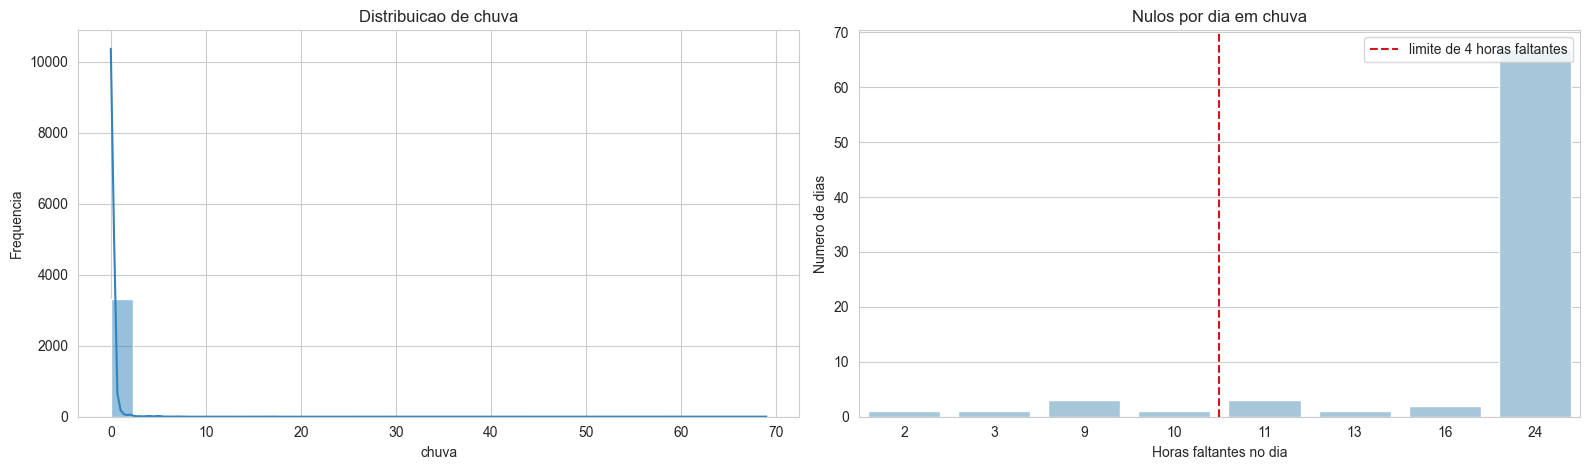

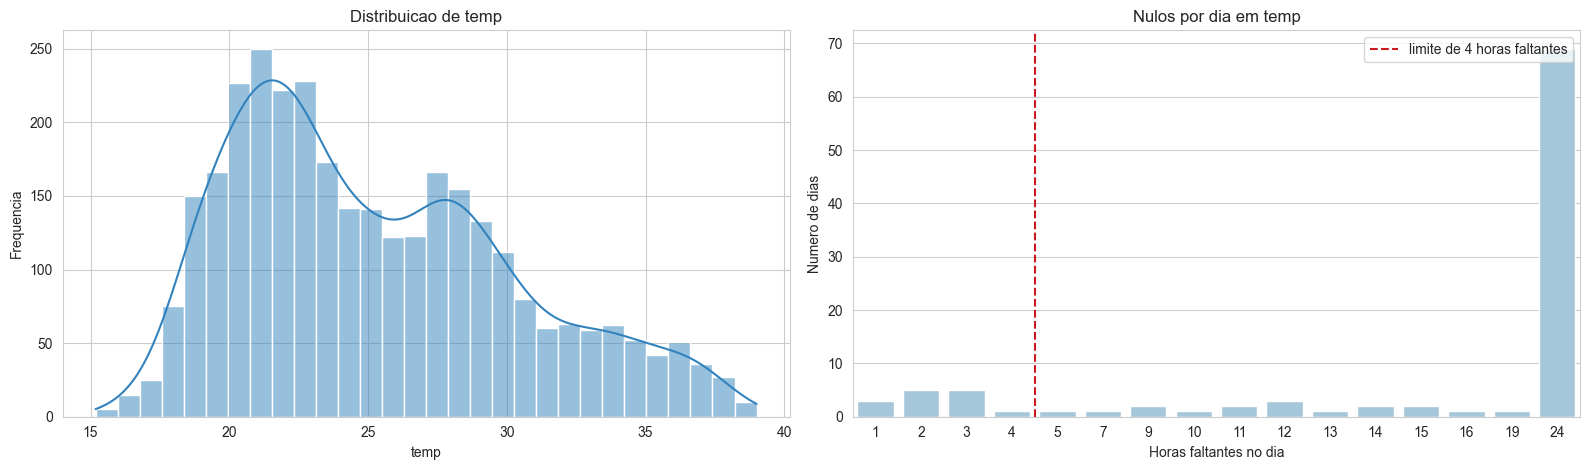

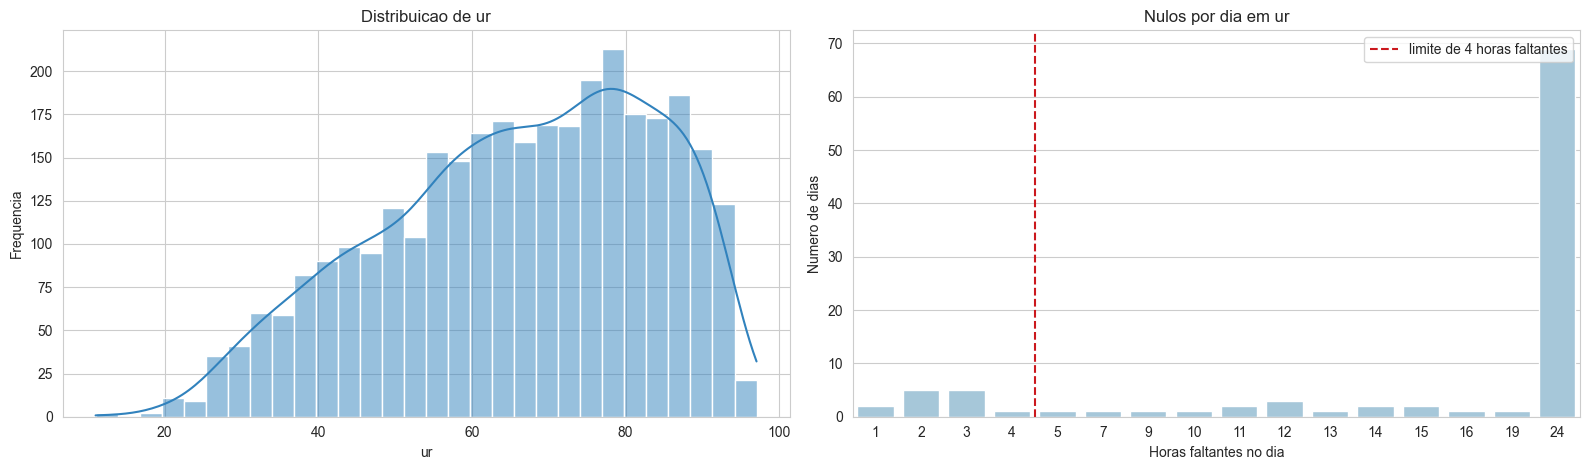

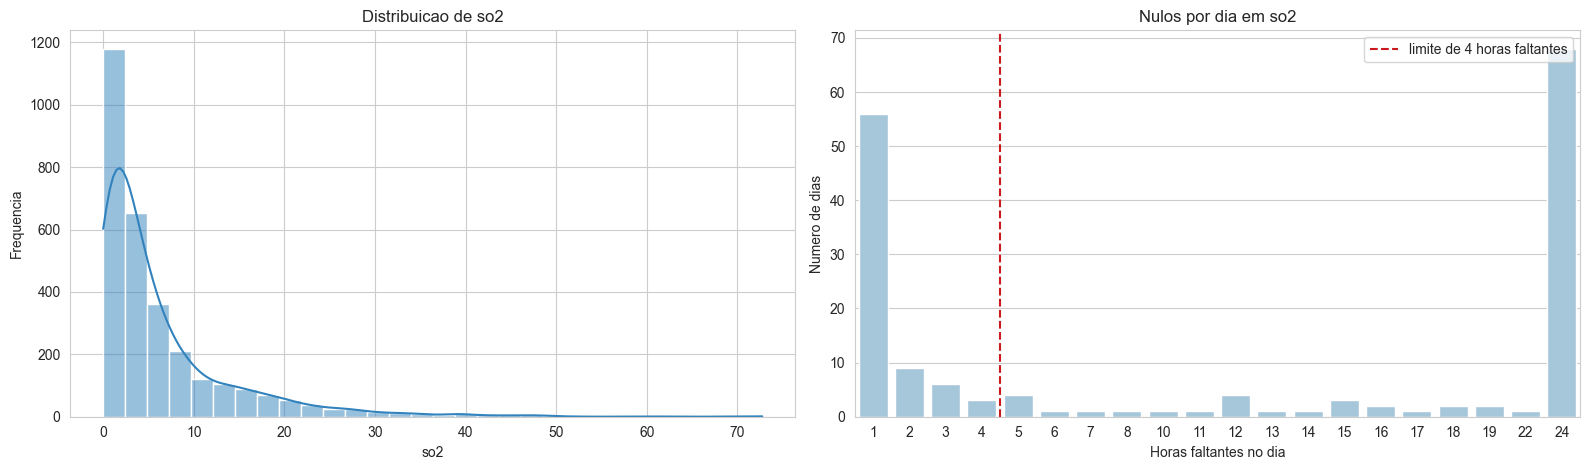

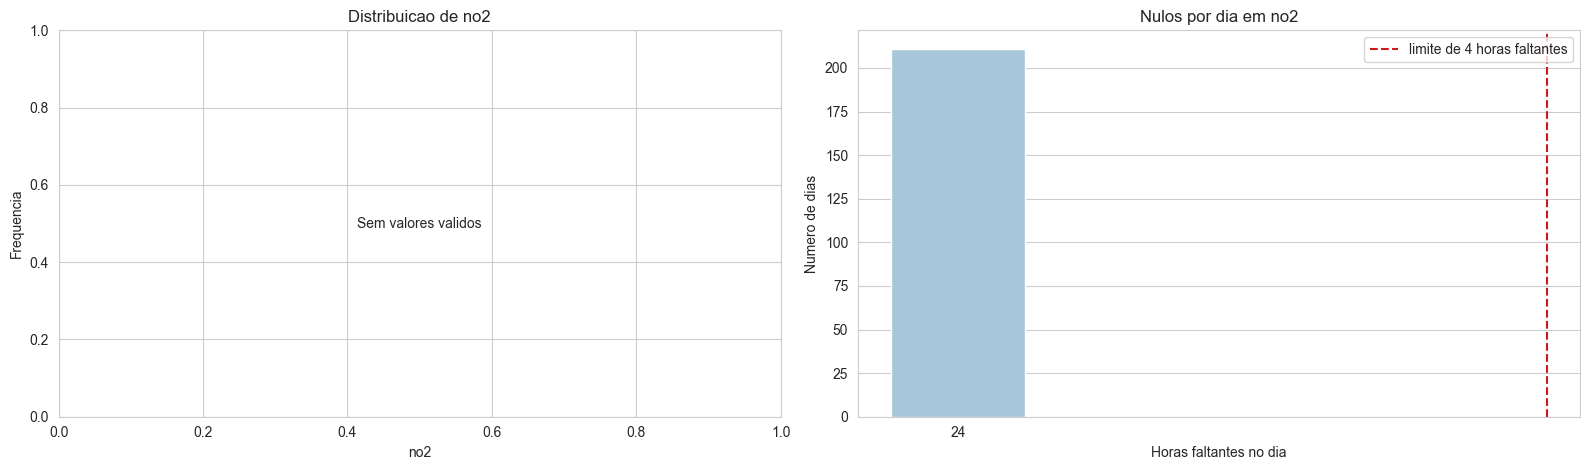

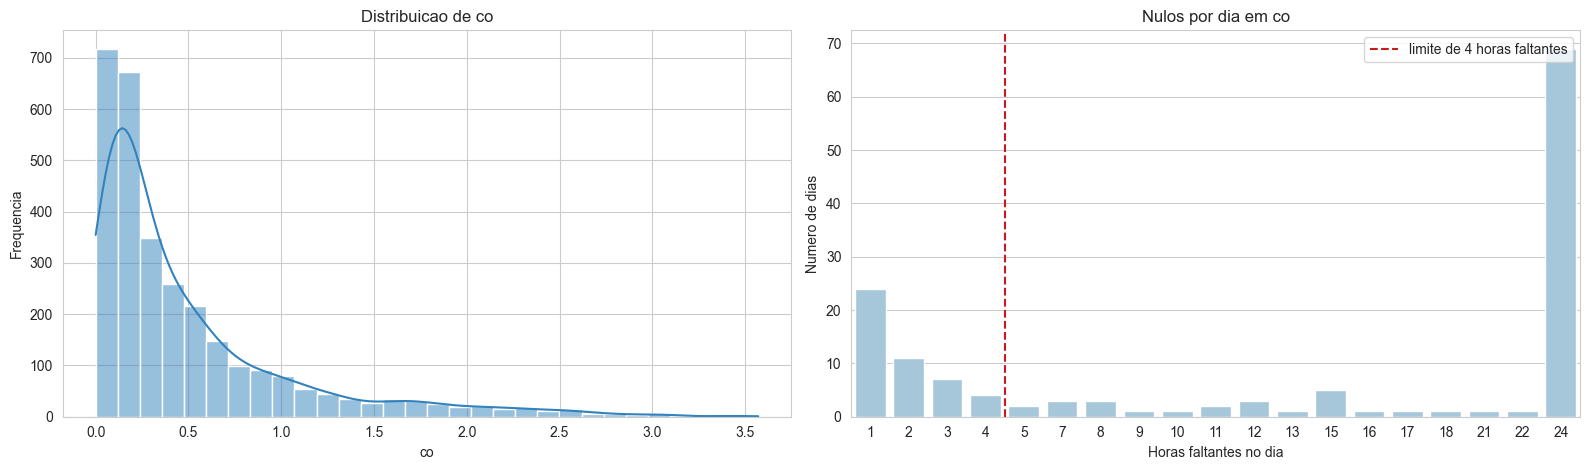

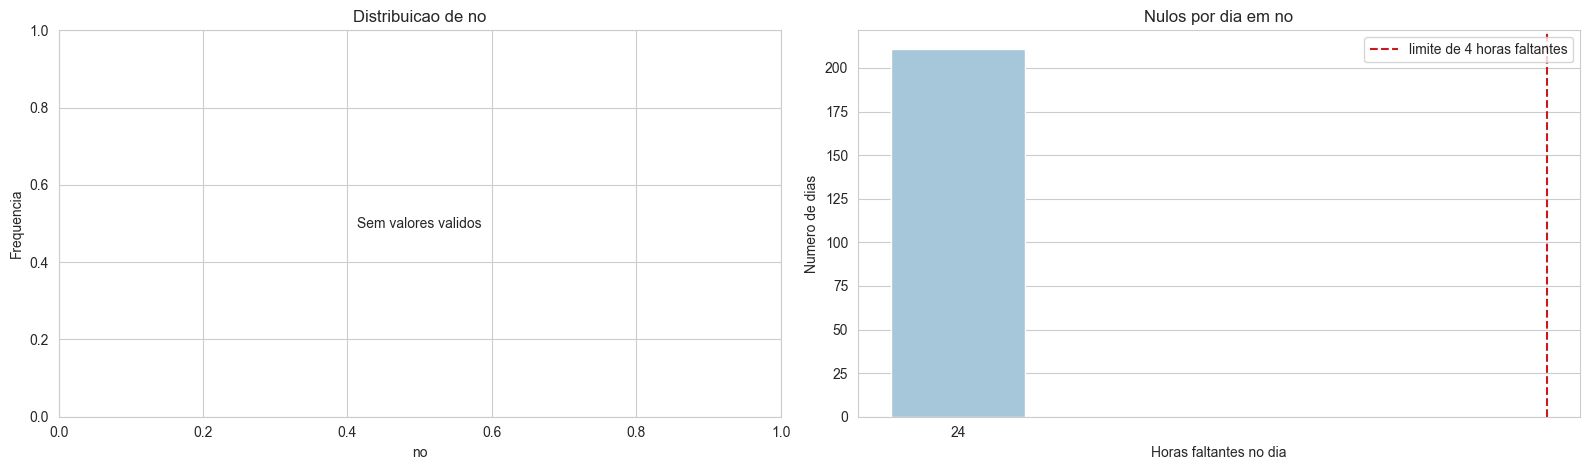

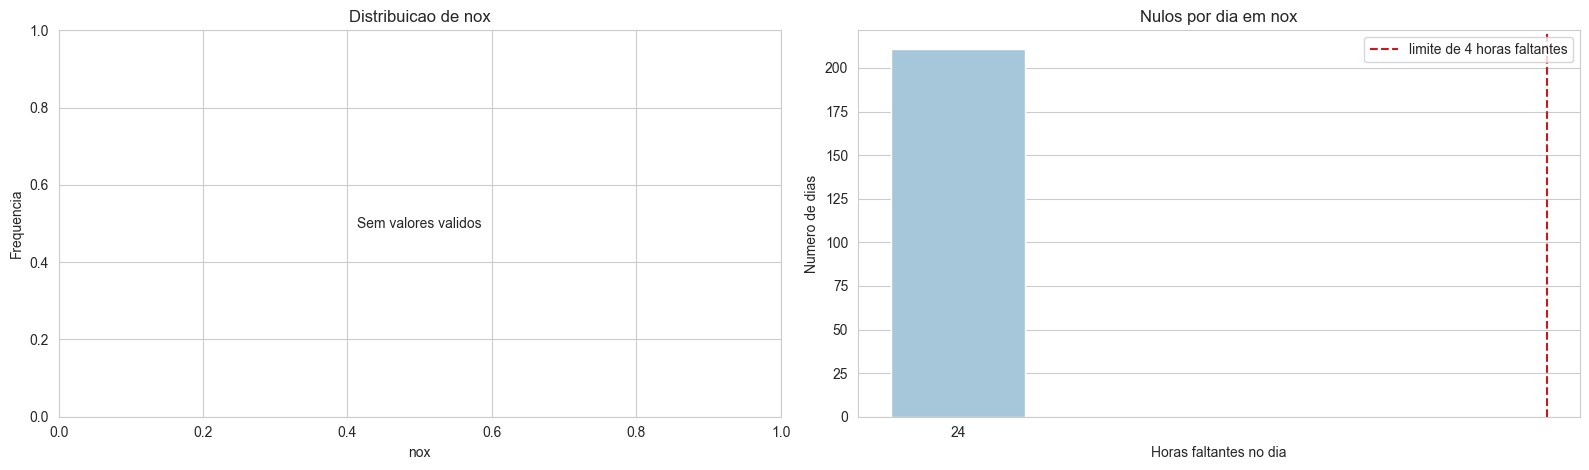

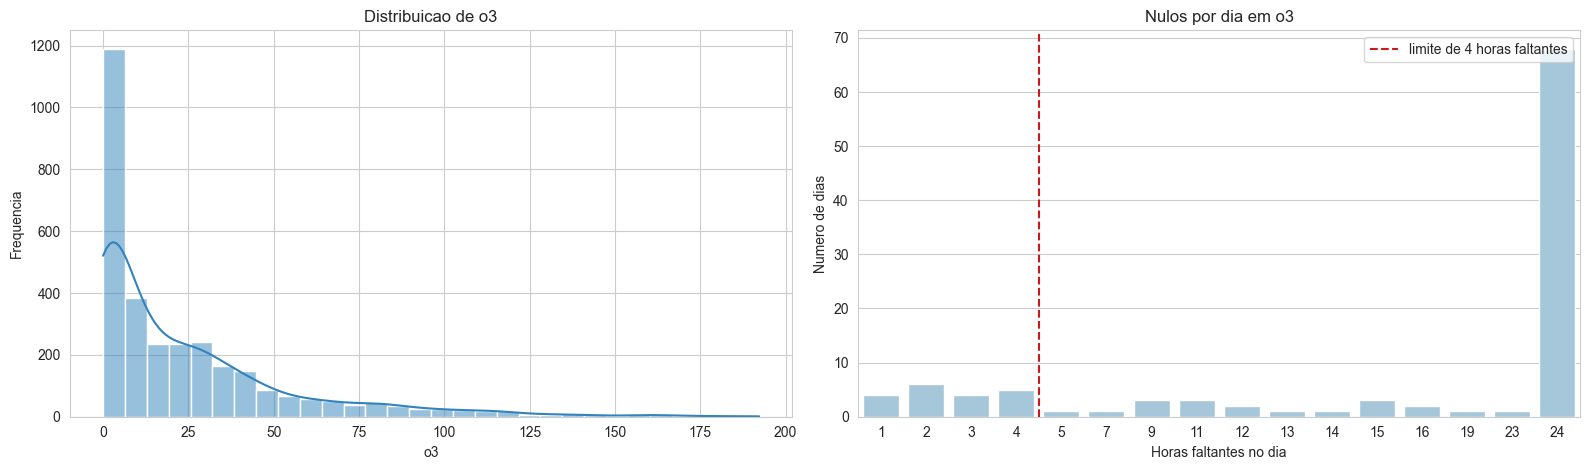

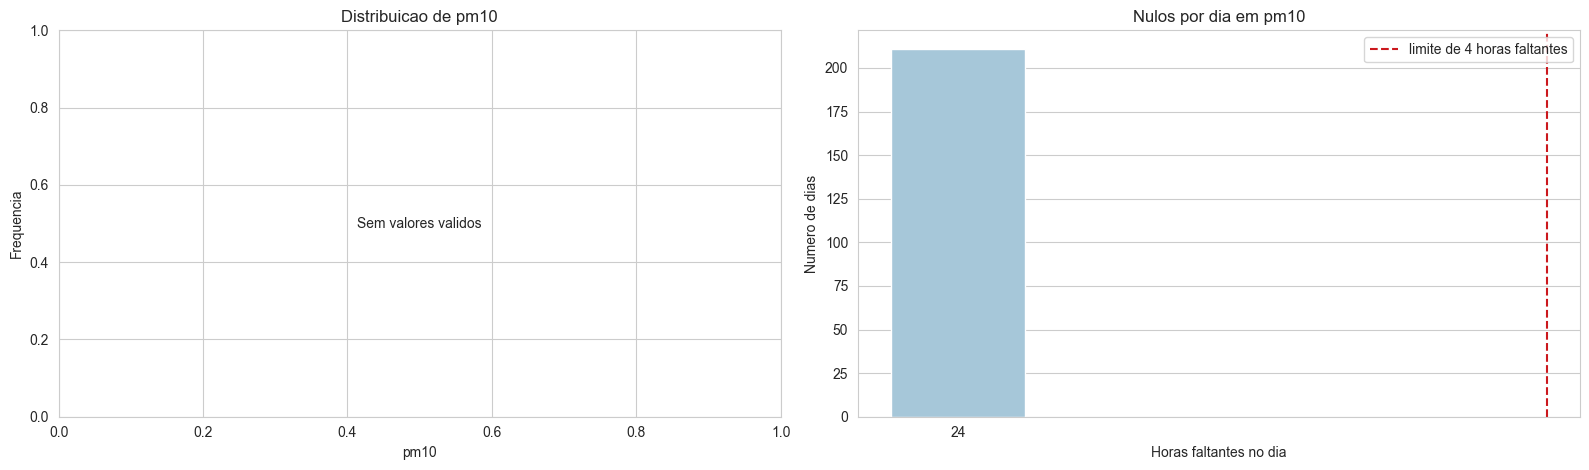

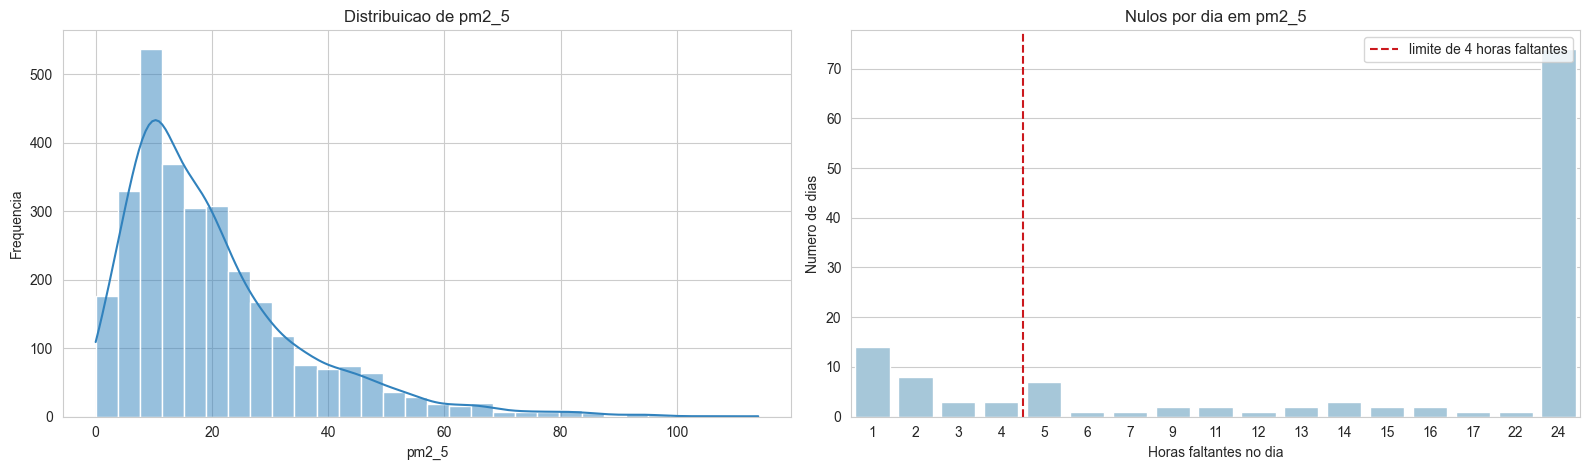

In [9]:
sns.set_style("whitegrid")

for variavel in variaveis_analise:
    serie = df_madureira_carac[variavel].dropna()
    faltantes_por_dia = distribuicoes_missing_diario[variavel]
    distribuicao_faltantes = (
        faltantes_por_dia.value_counts()
        .sort_index()
        .rename_axis("horas_faltantes")
        .reset_index(name="n_dias")
    )
    distribuicao_faltantes = distribuicao_faltantes[distribuicao_faltantes["horas_faltantes"] > 0].copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

    if not serie.empty:
        sns.histplot(serie, bins=30, kde=True, color="#3182bd", ax=axes[0])
    else:
        axes[0].text(0.5, 0.5, "Sem valores validos", ha="center", va="center", transform=axes[0].transAxes)

    axes[0].set_title(f"Distribuicao de {variavel}")
    axes[0].set_xlabel(variavel)
    axes[0].set_ylabel("Frequencia")

    if not distribuicao_faltantes.empty:
        sns.barplot(data=distribuicao_faltantes, x="horas_faltantes", y="n_dias", color="#9ecae1", ax=axes[1])
        axes[1].axvline(3.5, color="#cb181d", linestyle="--", linewidth=1.5, label="limite de 4 horas faltantes")
        axes[1].legend(loc="upper right")
    else:
        axes[1].text(0.5, 0.5, "Sem dias com horas faltantes", ha="center", va="center", transform=axes[1].transAxes)

    axes[1].set_title(f"Nulos por dia em {variavel}")
    axes[1].set_xlabel("Horas faltantes no dia")
    axes[1].set_ylabel("Numero de dias")

    plt.tight_layout()
    plt.show()

## Resumo interpretativo dos resultados

Os resultados indicam que a Unidade Movel Madureira tem uma base **razoavel do ponto de vista temporal e operacional**, mas com um perfil mais fragil do que o de outras unidades de campanha. A serie cobre o periodo de `2014-01-14 10:30` a `2014-08-12 14:30`, sem duplicatas de horario e com estabilidade de nome e coordenadas. O principal ponto de atencao esta no calendario: ha `1555` timestamps faltantes em `5045` esperados, o que indica descontinuidade relevante dentro da janela observada. Assim, nesta unidade, o cuidado analitico deve considerar nao apenas a completude das variaveis, mas tambem a irregularidade temporal da propria serie.

A leitura de missing por variavel mostra uma separacao bem definida de qualidade. `no`, `no2`, `nox` e `pm10` estao estruturalmente indisponiveis (`100%` de nulos) e, neste recorte, nao devem ser tratados como series analisaveis. Entre as variaveis disponiveis, `pm2_5` (`15,0%`), `so2` (`14,0%`) e `co` (`13,7%`) sao as mais criticas em completude, enquanto `o3` (`10,0%`), `temp` (`9,1%`) e `ur` (`8,8%`) tambem exigem alguma cautela. `chuva` (`4,4%`) e a serie mais completa da unidade. Em termos praticos, Madureira preserva um conjunto util de variaveis, mas com perdas mais altas e menos estabilidade geral do que outras unidades moveis.

As distribuicoes reforcam que a unidade monitora processos heterogeneos com sinal urbano forte. Entre as variaveis meteorologicas, `chuva` segue fortemente concentrada em zero e muito assimetrica, enquanto `temp` e `ur` apresentam comportamento mais estavel. Entre os poluentes efetivamente disponiveis, `co`, `o3`, `pm2_5` e `so2` mostram **assimetria a direita**, indicando predominancia de valores usuais com alguns episodios elevados. Em Madureira, chama atencao o nivel relativamente alto de `co` (`0,49` de media), `pm2_5` (`20,0`) e `so2` (`6,25`), alem de picos relevantes em `o3`, `pm2_5` e `so2`. Isso sugere uma unidade potencialmente util para estudar poluicao urbana e particulados finos, mas em um contexto de campanha mais irregular.

A distribuicao diaria de nulos tambem ajuda a separar o que e lacuna curta do que e perda mais severa. `temp`, `ur`, `co`, `o3` e `pm2_5` ainda preservam uma parcela importante de dias completos e um conjunto relevante de dias com apenas `1` a `4` horas faltantes, o que sustenta imputacao pontual em parte da serie. `so2` chama atencao por concentrar muitos dias com lacunas curtas, mas tambem varios dias severamente incompletos, o que exige cautela adicional. Ja `no`, `no2`, `nox` e `pm10` nao apresentam um problema de lacuna curta: essas series estao estruturalmente ausentes. Alem disso, como ha muitos timestamps faltantes na linha do tempo, qualquer estrategia de preenchimento precisa distinguir lacunas dentro de dias observados de periodos inteiros sem monitoramento.

Em sintese, a Unidade Movel Madureira parece **util como base exploratoria de campanha**, mas mais limitada do que outras unidades moveis por causa da descontinuidade temporal relevante. O principal cuidado analitico passa a ser tratar cada variavel conforme sua qualidade: `no`, `no2`, `nox` e `pm10` devem ser excluidos ou marcados como indisponiveis, `pm2_5`, `so2` e `co` exigem maior controle de completude, e `chuva`, `temp`, `ur` e `o3` podem seguir com utilidade para as proximas etapas da EDA. Isso deixa claro que, nesta unidade, a confiabilidade e moderada no nivel da base e a capacidade analitica fica concentrada em um subconjunto especifico de variaveis, dentro de uma janela curta e irregular de observacao.
